Loaded shape: (2872533, 56)
Shape after activity filtering: (1291362, 56)
Remaining activities: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(12), np.int64(13)]
Shape after dropping orientation columns: (1291362, 44)
Shape after preprocessing: (1291362, 44)
Number of feature columns: 40
['heart_rate', 'hand_temp', 'hand_acc16_x', 'hand_acc16_y', 'hand_acc16_z', 'hand_acc6_x', 'hand_acc6_y', 'hand_acc6_z', 'hand_gyro_x', 'hand_gyro_y', 'hand_gyro_z', 'hand_mag_x', 'hand_mag_y', 'hand_mag_z', 'chest_temp', 'chest_acc16_x', 'chest_acc16_y', 'chest_acc16_z', 'chest_acc6_x', 'chest_acc6_y', 'chest_acc6_z', 'chest_gyro_x', 'chest_gyro_y', 'chest_gyro_z', 'chest_mag_x', 'chest_mag_y', 'chest_mag_z', 'ankle_temp', 'ankle_acc16_x', 'ankle_acc16_y', 'ankle_acc16_z', 'ankle_acc6_x', 'ankle_acc6_y', 'ankle_acc6_z', 'ankle_gyro_x', 'ankle_gyro_y', 'ankle_gyro_z', 'ankle_mag_x', 'ankle_mag_y', 'ankle_mag_z']
Train shape: (815174, 44)
Val shape: (158856, 44)


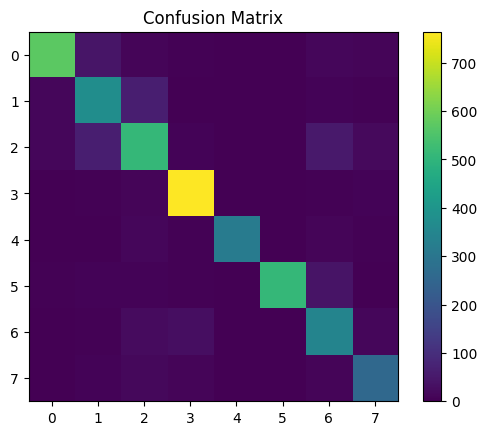

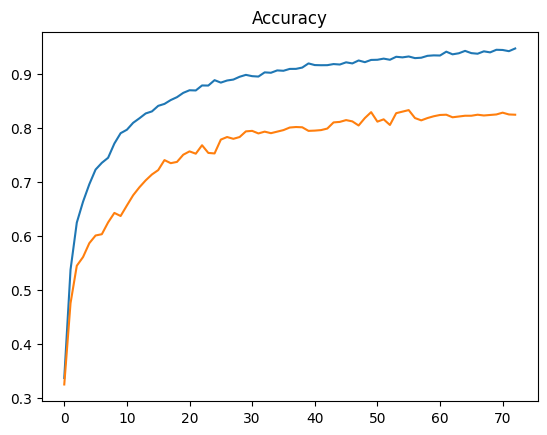

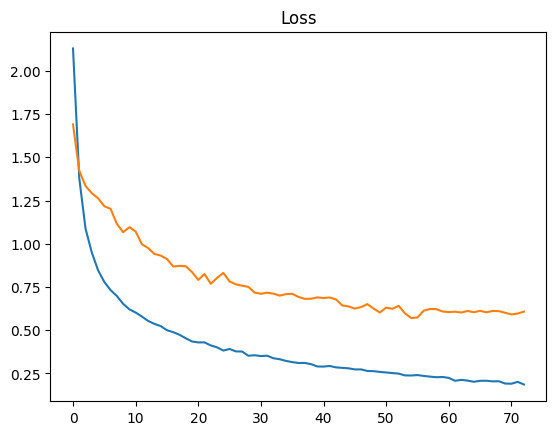

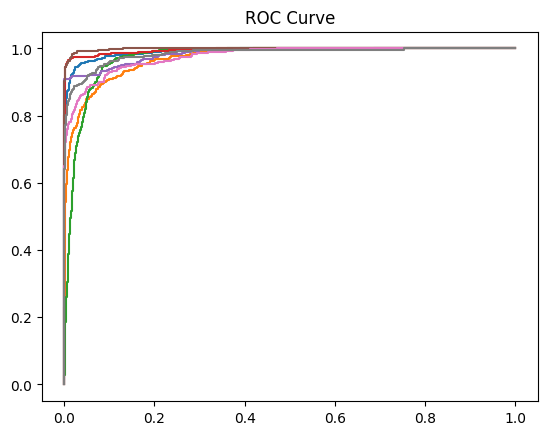

In [1]:
# 1-D CNN code for HAR 

import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input, Conv1D, BatchNormalization, MaxPooling1D,
    Dropout, GlobalAveragePooling1D, Dense
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.regularizers import l2

# Load dataset

base_path = r"C:\Users\Hari\Desktop\Artificial intelligence\PAMAP2_Dataset\PAMAP2_Dataset\Protocol"

file_map = {
    101: "subject101.dat",
    102: "subject102.dat",
    103: "subject103.dat",
    104: "subject104.dat",
    105: "subject105.dat",
    106: "subject106.dat",
    107: "subject107.dat",
    108: "subject108.dat",
    109: "subject109.dat"
}

columns = [
    "timestamp", "activityID", "heart_rate",
    "hand_temp", "hand_acc16_x", "hand_acc16_y", "hand_acc16_z",
    "hand_acc6_x", "hand_acc6_y", "hand_acc6_z",
    "hand_gyro_x", "hand_gyro_y", "hand_gyro_z",
    "hand_mag_x", "hand_mag_y", "hand_mag_z",
    "hand_orient_1", "hand_orient_2", "hand_orient_3", "hand_orient_4",
    "chest_temp", "chest_acc16_x", "chest_acc16_y", "chest_acc16_z",
    "chest_acc6_x", "chest_acc6_y", "chest_acc6_z",
    "chest_gyro_x", "chest_gyro_y", "chest_gyro_z",
    "chest_mag_x", "chest_mag_y", "chest_mag_z",
    "chest_orient_1", "chest_orient_2", "chest_orient_3", "chest_orient_4",
    "ankle_temp", "ankle_acc16_x", "ankle_acc16_y", "ankle_acc16_z",
    "ankle_acc6_x", "ankle_acc6_y", "ankle_acc6_z",
    "ankle_gyro_x", "ankle_gyro_y", "ankle_gyro_z",
    "ankle_mag_x", "ankle_mag_y", "ankle_mag_z",
    "ankle_orient_1", "ankle_orient_2", "ankle_orient_3", "ankle_orient_4"
]

all_subjects = []

for subject_id, file_name in file_map.items():
    path = f"{base_path}\\{file_name}"
    df = pd.read_csv(path, sep=r"\s+", header=None, names=columns)
    df["subject_id"] = subject_id
    df["session"] = 1
    all_subjects.append(df)

subjects = pd.concat(all_subjects, ignore_index=True)

print("Loaded shape:", subjects.shape)

# Filter activities

target_activities = [1, 2, 3, 4, 5, 6, 12, 13]
subjects = subjects[subjects["activityID"].isin(target_activities)].copy()

print("Shape after activity filtering:", subjects.shape)
print("Remaining activities:", sorted(subjects["activityID"].unique()))

# Drop orientation columns

orientation_cols = [col for col in subjects.columns if "orient" in col]
subjects.drop(columns=orientation_cols, inplace=True)

print("Shape after dropping orientation columns:", subjects.shape)

# Handle missing values

subjects.replace([np.inf, -np.inf], np.nan, inplace=True)

group_cols = ["subject_id", "session", "activityID"]
sensor_cols = []

for col in subjects.columns:
    if col not in group_cols:
        sensor_cols.append(col)

subjects = subjects.sort_values(["subject_id", "session", "timestamp"])
subjects = subjects.reset_index(drop=True)

grouped = subjects.groupby(["subject_id", "session"])

for col in sensor_cols:
    subjects[col] = grouped[col].transform(
        lambda x: x.interpolate(method="linear", limit_direction="both")
    )

for col in sensor_cols:
    subjects[col] = grouped[col].transform(
        lambda x: x.ffill().bfill()
    )

subjects = subjects.dropna()
subjects = subjects.reset_index(drop=True)

print("Shape after preprocessing:", subjects.shape)

# Define features

drop_cols = ["timestamp", "activityID", "subject_id", "session"]
feature_cols = []

for col in subjects.columns:
    if col not in drop_cols:
        feature_cols.append(col)

print("Number of feature columns:", len(feature_cols))
print(feature_cols)

# Subject split

train_subjects = [101, 102, 103, 108, 109, 105]
val_subjects   = [104]
test_subjects  = [106, 107]

train_df = subjects[subjects["subject_id"].isin(train_subjects)].copy()
val_df   = subjects[subjects["subject_id"].isin(val_subjects)].copy()
test_df  = subjects[subjects["subject_id"].isin(test_subjects)].copy()

print("Train shape:", train_df.shape)
print("Val shape:", val_df.shape)
print("Test shape:", test_df.shape)

# Windowing

def create_windows(df, feature_cols, window_size=150, step_size=75):
    X = []
    y = []

    grouped = df.groupby(["subject_id", "session", "activityID"])

    for (subject_id, session, activity_id), group in grouped:
        group = group.sort_values("timestamp").reset_index(drop=True)
        feature_array = group[feature_cols].values

        start = 0
        while start + window_size <= len(group):
            end = start + window_size
            X.append(feature_array[start:end])
            y.append(activity_id)
            start += step_size

    return np.array(X, dtype=np.float32), np.array(y)

X_train, y_train = create_windows(train_df, feature_cols)
X_val, y_val = create_windows(val_df, feature_cols)
X_test, y_test = create_windows(test_df, feature_cols)

print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("X_test:", X_test.shape)

# Label encoding

label_encoder = LabelEncoder()

y_train_enc = label_encoder.fit_transform(y_train)
y_val_enc = label_encoder.transform(y_val)
y_test_enc = label_encoder.transform(y_test)

num_classes = len(label_encoder.classes_)

y_train_cat = to_categorical(y_train_enc, num_classes=num_classes)
y_val_cat = to_categorical(y_val_enc, num_classes=num_classes)
y_test_cat = to_categorical(y_test_enc, num_classes=num_classes)

# Class weights

class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train_enc),
    y=y_train_enc
)

class_weights = {}

for i, w in enumerate(class_weights_array):
    class_weights[i] = w

# Scaling

n_train, t_train, f_train = X_train.shape
n_val, t_val, f_val = X_val.shape
n_test, t_test, f_test = X_test.shape

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train.reshape(-1, f_train)).reshape(n_train, t_train, f_train)
X_val   = scaler.transform(X_val.reshape(-1, f_val)).reshape(n_val, t_val, f_val)
X_test  = scaler.transform(X_test.reshape(-1, f_test)).reshape(n_test, t_test, f_test)

# Normalize each window

def normalize_each_window(X):
    mean = np.mean(X, axis=1, keepdims=True)
    std = np.std(X, axis=1, keepdims=True) + 1e-6
    return (X - mean) / std

X_train = normalize_each_window(X_train)
X_val   = normalize_each_window(X_val)
X_test  = normalize_each_window(X_test)

# CNN model

tf.keras.backend.clear_session()

model = Sequential([
    Input(shape=(X_train.shape[1], X_train.shape[2])),

    Conv1D(32, 7, padding="same", activation="relu", kernel_regularizer=l2(1e-4)),
    BatchNormalization(),
    MaxPooling1D(2),
    Dropout(0.25),

    Conv1D(64, 5, padding="same", activation="relu", kernel_regularizer=l2(1e-4)),
    BatchNormalization(),
    MaxPooling1D(2),
    Dropout(0.30),

    Conv1D(128, 3, padding="same", activation="relu", kernel_regularizer=l2(1e-4)),
    BatchNormalization(),
    MaxPooling1D(2),
    Dropout(0.35),

    GlobalAveragePooling1D(),

    Dense(96, activation="relu", kernel_regularizer=l2(1e-4)),
    BatchNormalization(),
    Dropout(0.50),

    Dense(num_classes, activation="softmax")
])

model.compile(
    optimizer=Adam(learning_rate=0.0002),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

# Training

early_stop = EarlyStopping(monitor="val_loss", patience=18, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=6)

history = model.fit(
    X_train, y_train_cat,
    validation_data=(X_val, y_val_cat),
    epochs=80,
    batch_size=64,
    class_weight=class_weights,
    callbacks=[early_stop, reduce_lr]
)

# Evaluation

train_loss, train_acc = model.evaluate(X_train, y_train_cat, verbose=0)
val_loss, val_acc = model.evaluate(X_val, y_val_cat, verbose=0)
test_loss, test_acc = model.evaluate(X_test, y_test_cat, verbose=0)

print("Train Accuracy:", train_acc)
print("Validation Accuracy:", val_acc)
print("Test Accuracy:", test_acc)

# Prediction

y_pred_prob = model.predict(X_test)
y_pred_enc = np.argmax(y_pred_prob, axis=1)

# Report

print(classification_report(y_test_enc, y_pred_enc))

cm = confusion_matrix(y_test_enc, y_pred_enc)
print(cm)

# Graphs

import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

plt.imshow(cm)
plt.title("Confusion Matrix")
plt.colorbar()
plt.show()

plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])
plt.title("Accuracy")
plt.show()

plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])
plt.title("Loss")
plt.show()

y_test_bin = label_binarize(y_test_enc, classes=np.arange(num_classes))

for i in range(num_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_pred_prob[:, i])
    plt.plot(fpr, tpr)

plt.title("ROC Curve")
plt.show()